In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [3]:
df = pd.read_csv('/content/malicious_phish.csv')

df = df[['url', 'type']]
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [4]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['type'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

Label Mapping: {'benign': np.int64(0), 'defacement': np.int64(1), 'malware': np.int64(2), 'phishing': np.int64(3)}


In [5]:
X = df['url']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)

In [6]:
vectorizer = TfidfVectorizer(
    analyzer='char',        # VERY IMPORTANT (character-level learning)
    ngram_range=(3,5),      # learns patterns like "login", "://", etc.
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85661
           1       0.98      0.98      0.98     19332
           2       0.97      0.92      0.95      6451
           3       0.89      0.82      0.85     18795

    accuracy                           0.96    130239
   macro avg       0.95      0.93      0.94    130239
weighted avg       0.96      0.96      0.96    130239

Accuracy: 0.9561421693962638


In [9]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_vec, y_train)

y_pred_svm = svm_model.predict(X_test_vec)

print("\nSVM Results")
print(classification_report(y_test, y_pred_svm))

svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_acc)


SVM Results
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85661
           1       0.98      0.99      0.98     19332
           2       0.97      0.93      0.95      6451
           3       0.90      0.82      0.85     18795

    accuracy                           0.96    130239
   macro avg       0.95      0.93      0.94    130239
weighted avg       0.96      0.96      0.96    130239

SVM Accuracy: 0.9574013928239621


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)

print("\nNaive Bayes Results")
print(classification_report(y_test, y_pred_nb))

nb_acc = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_acc)


Naive Bayes Results
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     85661
           1       0.93      0.78      0.85     19332
           2       0.88      0.77      0.82      6451
           3       0.54      0.63      0.58     18795

    accuracy                           0.84    130239
   macro avg       0.81      0.77      0.79    130239
weighted avg       0.85      0.84      0.85    130239

Naive Bayes Accuracy: 0.843687374749499


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,        # reduce trees
    max_depth=8,
    max_features='sqrt',    # faster split
    n_jobs=-1,              # parallel processing
    random_state=5
)

rf_model.fit(X_train_vec, y_train)

y_pred_rf = rf_model.predict(X_test_vec)

print("\nRandom Forest Results")
print(classification_report(y_test, y_pred_rf))

rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)


Random Forest Results
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     85661
           1       0.91      0.89      0.90     19332
           2       0.96      0.70      0.81      6451
           3       0.91      0.13      0.23     18795

    accuracy                           0.84    130239
   macro avg       0.90      0.68      0.71    130239
weighted avg       0.86      0.84      0.80    130239

Random Forest Accuracy: 0.8425817151544468


In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=50,        # reduce trees
    max_depth=3,            # shallower trees
    learning_rate=0.2,      # faster convergence
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',     # MUCH faster
    n_jobs=-1               # use all CPU cores
)

xgb_model.fit(X_train_vec, y_train)

y_pred_xgb = xgb_model.predict(X_test_vec)

print("\nXGBoost Results")
print(classification_report(y_test, y_pred_xgb))

xgb_acc = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", xgb_acc)


XGBoost Results
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     85661
           1       0.92      0.94      0.93     19332
           2       0.95      0.83      0.89      6451
           3       0.84      0.64      0.73     18795

    accuracy                           0.92    130239
   macro avg       0.91      0.85      0.87    130239
weighted avg       0.92      0.92      0.91    130239

XGBoost Accuracy: 0.9181427990079777


In [13]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='log_loss',     # logistic regression style
    max_iter=1000,
    random_state=5
)

sgd_model.fit(X_train_vec, y_train)

y_pred_sgd = sgd_model.predict(X_test_vec)

print("\nSGD Classifier Results")
print(classification_report(y_test, y_pred_sgd))

sgd_acc = accuracy_score(y_test, y_pred_sgd)
print("SGD Accuracy:", sgd_acc)


SGD Classifier Results
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     85661
           1       0.93      0.93      0.93     19332
           2       0.95      0.78      0.86      6451
           3       0.86      0.49      0.63     18795

    accuracy                           0.90    130239
   macro avg       0.91      0.80      0.84    130239
weighted avg       0.90      0.90      0.89    130239

SGD Accuracy: 0.896574758712828


In [14]:
from sklearn.linear_model import PassiveAggressiveClassifier

pa_model = PassiveAggressiveClassifier(
    max_iter=1000,
    random_state=5
)

pa_model.fit(X_train_vec, y_train)

y_pred_pa = pa_model.predict(X_test_vec)

print("\nPassive Aggressive Results")
print(classification_report(y_test, y_pred_pa))

pa_acc = accuracy_score(y_test, y_pred_pa)
print("PA Accuracy:", pa_acc)


Passive Aggressive Results
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     85661
           1       0.98      0.98      0.98     19332
           2       0.96      0.94      0.95      6451
           3       0.87      0.84      0.85     18795

    accuracy                           0.96    130239
   macro avg       0.94      0.93      0.94    130239
weighted avg       0.96      0.96      0.96    130239

PA Accuracy: 0.9556354087485316


In [15]:
def predict_url(url):
    url_vec = vectorizer.transform([url])
    pred = model.predict(url_vec)[0]

    return le.inverse_transform([pred])[0]

In [16]:
url = input("Enter URL: ")

result = predict_url(url)

print("\nPrediction:", result)

Enter URL: https://www.kaggle.com/code/sid321axn/malicious-url-detection-using-ml-feat-engg

Prediction: phishing


In [17]:
models = {
    "1": ("Logistic Regression", model),
    "2": ("SVM", svm_model),
    "3": ("Naive Bayes", nb_model),
    "4": ("Random Forest", rf_model),
    "5": ("XGBoost", xgb_model),
    "6": ("SGD Classifier", sgd_model),
    "7": ("Passive Aggressive", pa_model)
}

In [18]:
def predict_url_with_model(url, model):
    url_vec = vectorizer.transform([url])
    pred = model.predict(url_vec)[0]
    return le.inverse_transform([pred])[0]

In [19]:
print("\n====== URL Phishing Detection System ======")
print("Select Model:\n")

for key, value in models.items():
    print(f"{key}. {value[0]}")

choice = input("\nEnter model number: ")

if choice not in models:
    print("❌ Invalid choice. Please restart.")
else:
    url = input("\nEnter URL: ")

    model_name, selected_model = models[choice]

    result = predict_url_with_model(url, selected_model)

    print("\n====================================")
    print(f"Model Used   : {model_name}")
    print(f"Prediction   : {result}")
    print("====================================")


====== URL Phishing Detection System ======
Select Model:

1. Logistic Regression
2. SVM
3. Naive Bayes
4. Random Forest
5. XGBoost
6. SGD Classifier
7. Passive Aggressive

Enter model number: 7

Enter URL: https://www.kaggle.com/code/sid321axn/malicious-url-detection-using-ml-feat-engg

Model Used   : Passive Aggressive
Prediction   : phishing


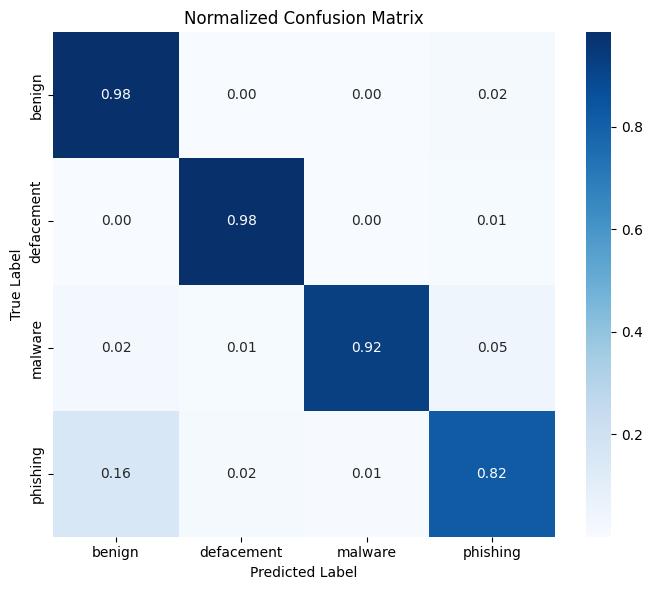

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(X_test_vec)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize (for better interpretation)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',          # show percentages
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cbar=True)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

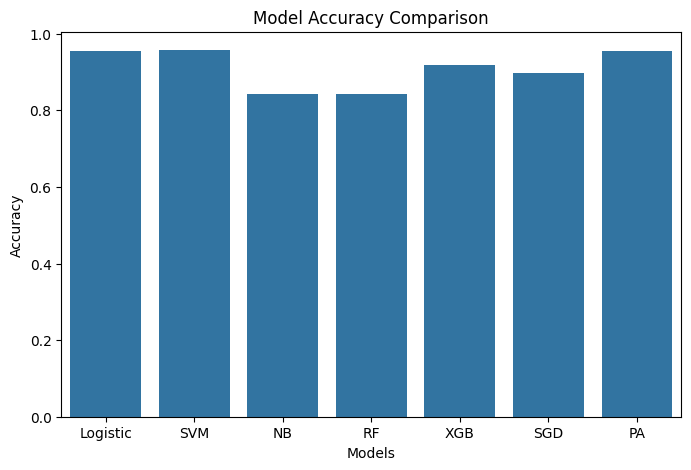

In [21]:
model_names = ["Logistic", "SVM", "NB", "RF", "XGB", "SGD", "PA"]
accuracies = [acc, svm_acc, nb_acc, rf_acc, xgb_acc, sgd_acc, pa_acc]

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

In [22]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred
)

metrics_df = pd.DataFrame({
    'Class': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1': f1
})

print(metrics_df)

        Class  Precision    Recall        F1
0      benign   0.963980  0.981929  0.972871
1  defacement   0.976955  0.984637  0.980781
2     malware   0.972417  0.923578  0.947368
3    phishing   0.887693  0.820484  0.852766


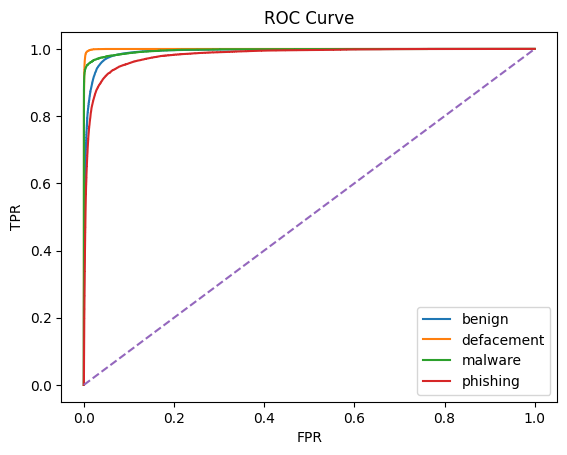

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
y_score = model.predict_proba(X_test_vec)

plt.figure()

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=le.classes_[i])

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

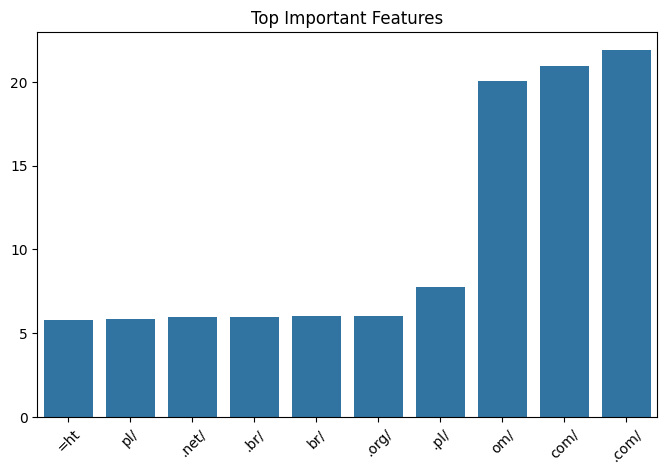

In [24]:
feature_names = vectorizer.get_feature_names_out()

top_features = np.argsort(model.coef_[0])[-10:]

plt.figure(figsize=(8,5))
sns.barplot(x=feature_names[top_features], y=model.coef_[0][top_features])

plt.title("Top Important Features")
plt.xticks(rotation=45)
plt.show()

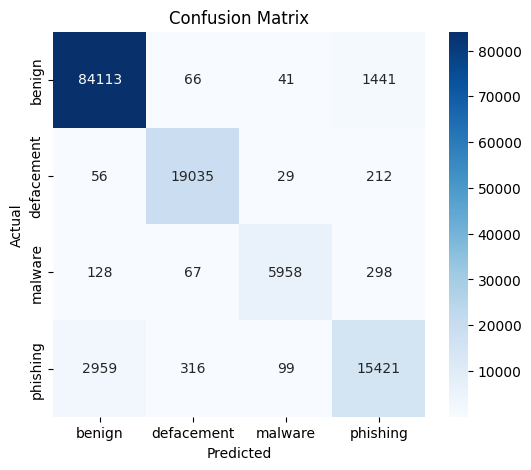

In [25]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

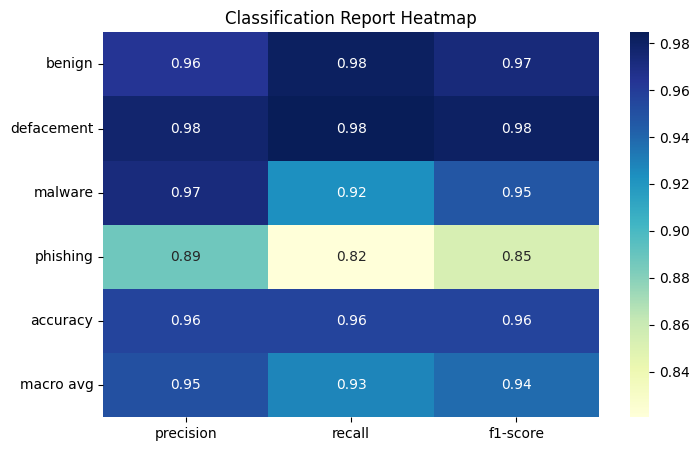

In [32]:
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Generate report
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Remove support column (optional for cleaner heatmap)
report_df = report_df.iloc[:-1, :-1]

plt.figure(figsize=(8,5))
sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title("Classification Report Heatmap")
plt.show()